# XGBoost–FNN Hybrid Model for Wind Speed Forecasting
## Multivariate Standalone Optimal Model with Residual Correction
### Sections: Original Model | Grid Search | Randomized Search | Optuna


## 1. Installing Required Packages

In [1]:
# INSTALLING REQUIRED PACKAGES
!pip install statsmodels optuna tabulate xgboost --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.4 MB/s eta 0:00:00


## 2. Imports & Global Settings

In [2]:
# Standard libraries
import sys
import os
import warnings
import random
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np   # Numerical operations
import pandas as pd  # Data manipulation and analysis

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (TimeSeriesSplit, GridSearchCV,
                                     RandomizedSearchCV)

# Neural network
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score)

# Permutation importance
from sklearn.inspection import permutation_importance

# Scipy distributions (used in Randomized Search)
from scipy.stats import uniform

# XGBoost
import xgboost as xgb

# Optuna (Bayesian hyperparameter optimisation)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose trial logs

# ── Global random seed (set once here; reused throughout) ──────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Global random seed set to {RANDOM_SEED}")


Global random seed set to 42


## 3. Loading the Dataset

In [3]:
# =============================================================================
# LOADING THE DATASET
# Dataset source:
#   https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
#   https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing
# =============================================================================

file_id      = "1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk"   # Variable Set 2 dataset
download_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(download_url)

# Create a proper datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year':  df['YEAR'],
    'month': df['MO'],
    'day':   df['DY']
})
df = df.set_index('Date')

# Drop the raw date columns (now encoded in the index)
df = df.drop(columns=["YEAR", "MO", "DY"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())


Dataset loaded successfully.
Shape: (4015, 14)

First 5 rows:


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66



Column names:
['WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin', 'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1', 'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP', 'SL_PRESSURE_lag1', 'CLOUD_COVER', 'WS10M']


## 4. Primary Train–Test Split (80 / 20, Time-Based)

In [4]:
# =============================================================================
# Train-test split — 80% first observations for training, last 20% for testing.
# Temporal ordering is preserved; no shuffling is applied.
# =============================================================================

X = df.drop(columns=['WS10M'])  # Features
y = df['WS10M']                 # Target: wind speed

split_index = int(len(X) * 0.8)  # 80% training, 20% testing

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

print(f"Total samples : {len(X)}")
print(f"Training set  : {X_train.shape}  ({split_index} samples)")
print(f"Test set      : {X_test.shape}  ({len(X) - split_index} samples)")
print(f"\nTrain period: {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Test period : {X_test.index[0].date()}  →  {X_test.index[-1].date()}")


Total samples : 4015
Training set  : (3212, 13)  (3212 samples)
Test set      : (803, 13)  (803 samples)

Train period: 2013-01-03  →  2021-10-19
Test period : 2021-10-20  →  2023-12-31


## 5. XGBoost Primary Model (Optuna-Optimised Parameters)
The XGBoost model was previously optimised with Optuna and produced the
following standalone optimal performance on wind-speed forecasting:

| Method | Train MSE | Test MSE | Train MAE | Test MAE | Train RMSE | Test RMSE | Train MAPE (%) | Test MAPE (%) | Train R² | Test R² |
|--------|-----------|----------|-----------|----------|------------|-----------|----------------|---------------|----------|---------|
| Optuna | 0.211530  | 0.527328 | 0.360631  | 0.551346 | 0.459923   | 0.726173  | 9.983644       | 14.987060     | 0.916036 | 0.781323|


In [5]:
# =============================================================================
# XGBoost with time-series cross-validation (primary model).
# Best parameters obtained from a prior Optuna optimisation run.
# The model is fitted once on X_train; residuals over the full dataset are
# used to train the FNN correction layer in subsequent sections.
# =============================================================================
#Best Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'min_child_weight': 5, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084}
# ── Best parameters from Optuna ─────────────────────────────────────────────
Best_Parameters = {
    'n_estimators':    300,
    'max_depth':       6,
    'learning_rate':   0.02017215364230889,
    'gamma':           0.019237778052053844,
    'subsample':       0.618408743715084,
    'min_child_weight': 5
}

# Initialise XGBRegressor with optimal parameters
best_xgb = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)

# Fit on training data only (no leakage of test information)
best_xgb.fit(X_train, y_train)
print(f"XGBoost model fitted.  Parameters: {Best_Parameters}")

# ── Predictions ──────────────────────────────────────────────────────────────
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb  = best_xgb.predict(X_test)

# ── Evaluation metrics ───────────────────────────────────────────────────────
xgb_train_mse  = mean_squared_error(y_train, y_train_pred_xgb)
xgb_test_mse   = mean_squared_error(y_test,  y_test_pred_xgb)
xgb_train_mae  = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae   = mean_absolute_error(y_test,  y_test_pred_xgb)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_test_rmse  = np.sqrt(xgb_test_mse)
xgb_train_mape = np.mean(np.abs((y_train - y_train_pred_xgb) / y_train)) * 100
xgb_test_mape  = np.mean(np.abs((y_test  - y_test_pred_xgb)  / y_test))  * 100
xgb_train_r2   = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2    = r2_score(y_test,  y_test_pred_xgb)

print(f"\nTrain MSE:  {xgb_train_mse:.4f}  | Test MSE:  {xgb_test_mse:.4f}")
print(f"Train MAE:  {xgb_train_mae:.4f}  | Test MAE:  {xgb_test_mae:.4f}")
print(f"Train RMSE: {xgb_train_rmse:.4f} | Test RMSE: {xgb_test_rmse:.4f}")
print(f"Train MAPE: {xgb_train_mape:.4f}%| Test MAPE: {xgb_test_mape:.4f}%")
print(f"Train R²:   {xgb_train_r2:.4f}  | Test R²:   {xgb_test_r2:.4f}")

# ── Summary table (Plotly) ───────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Parameter/Metric': list(Best_Parameters.keys()) +
                        ['Train MSE', 'Test MSE', 'Train MAE', 'Test MAE',
                         'Train RMSE', 'Test RMSE', 'Train MAPE (%)',
                         'Test MAPE (%)', 'Train R²', 'Test R²'],
    'Value': list(Best_Parameters.values()) +
             [xgb_train_mse, xgb_test_mse, xgb_train_mae, xgb_test_mae,
              xgb_train_rmse, xgb_test_rmse, xgb_train_mape, xgb_test_mape,
              xgb_train_r2, xgb_test_r2]
})
summary_df['Value'] = summary_df['Value'].apply(lambda x: f"{x:.6f}")

fig_table = go.Figure(go.Table(
    header=dict(
        values=['<b>Parameter / Metric</b>', '<b>Value</b>'],
        fill_color='steelblue',
        font=dict(color='white', size=13),
        align='left'
    ),
    cells=dict(
        values=[summary_df['Parameter/Metric'], summary_df['Value']],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(summary_df))]],
        align='left'
    )
))
fig_table.update_layout(
    title="XGBoost Optimal Parameters & Model Performance Metrics",
    template="plotly_white",
    height=600
)
fig_table.show()


XGBoost model fitted.  Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084, 'min_child_weight': 5}

Train MSE:  0.2115  | Test MSE:  0.5273
Train MAE:  0.3606  | Test MAE:  0.5513
Train RMSE: 0.4599 | Test RMSE: 0.7262
Train MAPE: 9.9836%| Test MAPE: 14.9871%
Train R²:   0.9160  | Test R²:   0.7813


## 6. Full-Dataset XGBoost Predictions & Residuals

In [6]:
# =============================================================================
# Predict over the full dataset to generate residuals.
# Note: train-set residuals are in-sample; test-set residuals are out-of-sample.
# The FNN residual correction model is trained exclusively on in-sample residuals
# (first 80%) to avoid data leakage.
# =============================================================================

# Predict on the full dataset
y_pred_full_xgb = best_xgb.predict(X)

# Attach predictions and residuals to the main dataframe
df['Pred_XGB_Optuna'] = y_pred_full_xgb
df['Residual']        = df['WS10M'] - df['Pred_XGB_Optuna']

print("Predictions and residuals added to dataframe.")
print(df[['WS10M', 'Pred_XGB_Optuna', 'Residual']].head(10))

# Backup the enriched dataframe (used by all hybrid model sections below)
df_backup = df.copy()

# ── Visualise actual vs predicted + residuals ────────────────────────────────
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Actual vs Predicted Wind Speed (XGB Optuna)", "Residuals"),
    shared_xaxes=True,
    vertical_spacing=0.12
)

fig.add_trace(go.Scatter(
    x=df.index, y=df['WS10M'],
    mode='lines', name='Actual WS10M',
    line=dict(color='steelblue', width=1.5)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df.index, y=df['Pred_XGB_Optuna'],
    mode='lines', name='Predicted (XGB Optuna)',
    line=dict(color='orange', width=1.5, dash='dot')
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df.index, y=df['Residual'],
    mode='lines', name='Residual',
    line=dict(color='crimson', width=1)
), row=2, col=1)

fig.add_hline(y=0, line_dash="dash", line_color="black", row=2, col=1)

fig.update_layout(
    height=700, template="plotly_white",
    title="XGBoost Optuna — Full Dataset Predictions & Residuals",
    legend=dict(orientation="h", yanchor="bottom", y=1.02,
                xanchor="right", x=1)
)
fig.update_yaxes(title_text="Wind Speed (m/s)", row=1, col=1)
fig.update_yaxes(title_text="Residual",         row=2, col=1)
fig.update_xaxes(title_text="Date",             row=2, col=1)
fig.show()

# Save XGBoost predictions to CSV
df.to_csv('XGB_Primary_Model_Prediction.csv', index=True)
print("\nSaved to 'XGB_Primary_Model_Prediction.csv'")


Predictions and residuals added to dataframe.
            WS10M  Pred_XGB_Optuna  Residual
Date                                        
2013-01-03   4.75         4.469862  0.280138
2013-01-04   5.74         5.277423  0.462577
2013-01-05   5.79         5.620399  0.169601
2013-01-06   4.52         5.237511 -0.717511
2013-01-07   4.66         4.876992 -0.216992
2013-01-08   3.61         3.838809 -0.228809
2013-01-09   4.19         4.121636  0.068364
2013-01-10   5.41         4.998459  0.411541
2013-01-11   5.95         4.748426  1.201574
2013-01-12   5.80         5.402409  0.397591



Saved to 'XGB_Primary_Model_Prediction.csv'


## 7. FNN Residual Correction Model — Data Preparation

The FNN is trained to predict the residuals left by XGBoost.
The hybrid forecast is then:  **Ŷ_hybrid = Ŷ_XGB + Ŷ_FNN_residual**

Features used for residual correction are selected based on domain knowledge
and prior feature-importance analysis.


In [7]:
# =============================================================================
# Feature set for FNN residual correction model
# =============================================================================

fnn_features = [
    'WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin',
    'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1',
    'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP',
    'SL_PRESSURE_lag1', 'CLOUD_COVER'
]

X_res = df[fnn_features]  # Features for residual correction
y_res = df['Residual']    # Target: XGBoost residuals

# Same 80 / 20 temporal split as the primary model
split_index_res = int(len(X_res) * 0.8)

X_train_res = X_res.iloc[:split_index_res]
y_train_res = y_res.iloc[:split_index_res]
X_test_res  = X_res.iloc[split_index_res:]
y_test_res  = y_res.iloc[split_index_res:]

print(f"FNN residual model — training samples : {X_train_res.shape[0]}")
print(f"FNN residual model — test samples     : {X_test_res.shape[0]}")

# ── Shared helper functions ──────────────────────────────────────────────────
def evaluate(y_true, y_pred, label=""):
    """Print and return evaluation metrics for the residual model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2

def evaluate_performance(y_true, y_pred, set_name="Dataset"):
    """Evaluate and return metrics as a dictionary for the hybrid model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n--- {set_name} Metrics ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R²:   {r2:.4f}")
    return {'RMSE': rmse, 'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R²': r2}


FNN residual model — training samples : 3212
FNN residual model — test samples     : 803


## 8. FNN Residual Correction — Original Model (No Hyperparameter Optimisation)

--- Original FNN Residual Model Evaluation ---
Train (FNN Original) MSE:  0.0739
Train (FNN Original) RMSE: 0.2719
Train (FNN Original) MAE:  0.2100
Train (FNN Original) MAPE: 1925.11%
Train (FNN Original) R²:   0.6505
Test  (FNN Original) MSE:  0.6124
Test  (FNN Original) RMSE: 0.7826
Test  (FNN Original) MAE:  0.6087
Test  (FNN Original) MAPE: 297.73%
Test  (FNN Original) R²:   -0.1617

=== Hybrid XGB-FNN (Original) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.2719
MSE:  0.0739
MAE:  0.2100
MAPE: 5.7245%
R²:   0.9707

--- Test Metrics ---
RMSE: 0.7826
MSE:  0.6124
MAE:  0.6087
MAPE: 16.7268%
R²:   0.7460


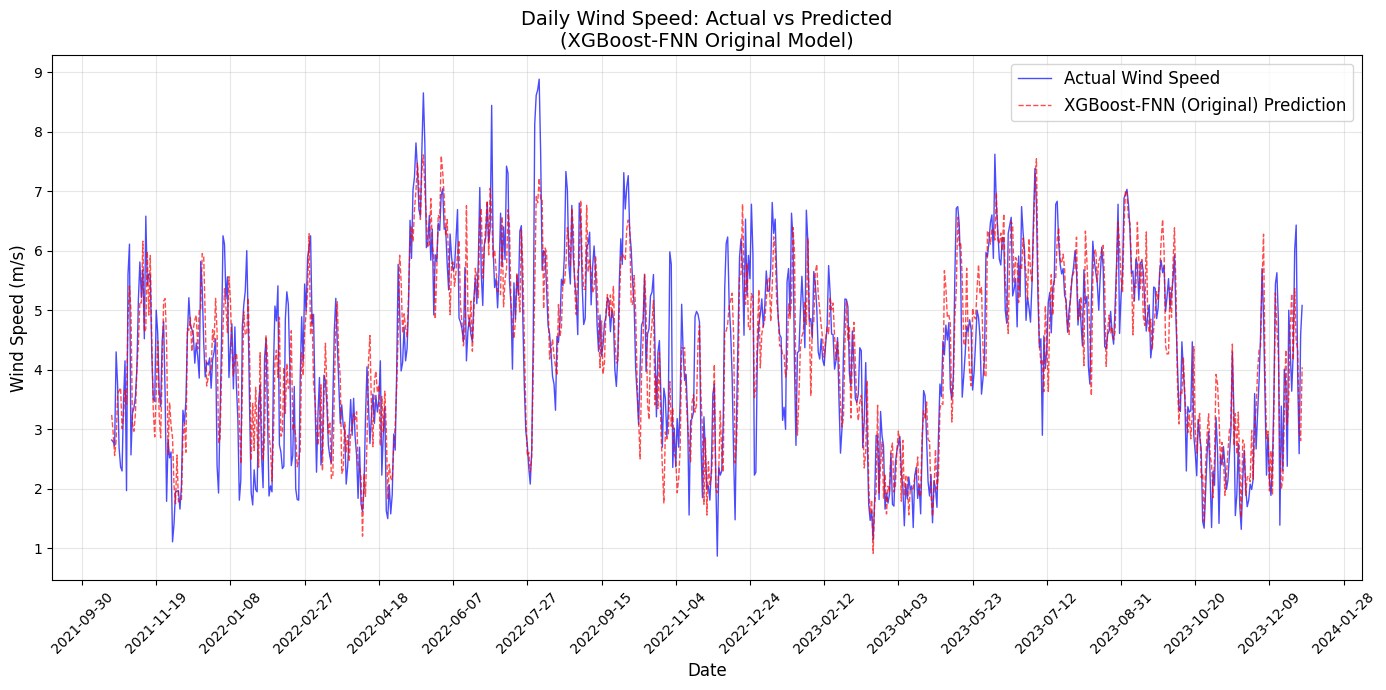

Saved to 'xgb_fnn_df_original.csv'


In [ ]:
# =============================================================================
# Section 1 — Original FNN model
# Default architecture: two hidden layers (100, 50 neurons).
# No hyperparameter search is performed in this section.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ────────────────────────
scaler_original      = StandardScaler()
X_train_scaled_orig  = scaler_original.fit_transform(X_train_res)
X_test_scaled_orig   = scaler_original.transform(X_test_res)

# ── Model definition ─────────────────────────────────────────────────────────
fnn_original = MLPRegressor(
    hidden_layer_sizes=(100, 50),  # Two hidden layers
    activation='relu',             # ReLU activation function
    solver='adam',                 # Adam optimiser
    learning_rate='adaptive',      # Adaptive learning rate
    max_iter=1000,
    random_state=RANDOM_SEED
)

# Fit on training residuals only
fnn_original.fit(X_train_scaled_orig, y_train_res)

# ── Residual model evaluation ────────────────────────────────────────────────
y_train_pred_orig = fnn_original.predict(X_train_scaled_orig)
y_test_pred_orig  = fnn_original.predict(X_test_scaled_orig)

print("--- Original FNN Residual Model Evaluation ---")
evaluate(y_train_res, y_train_pred_orig, label="Train (FNN Original)")
evaluate(y_test_res,  y_test_pred_orig,  label="Test  (FNN Original)")

# ── Predict residuals on full dataset ────────────────────────────────────────
X_full_scaled_orig           = scaler_original.transform(X_res)
full_pred_residuals_original  = fnn_original.predict(X_full_scaled_orig).flatten()

df_backup['predicted_residuals_fnn_original'] = full_pred_residuals_original

# ── Hybrid prediction: XGB + FNN residual correction ────────────────────────
df_backup['XGB_fnn_original'] = (df_backup['Pred_XGB_Optuna'] +
                                  df_backup['predicted_residuals_fnn_original'])

# ── Hybrid model performance ─────────────────────────────────────────────────
train_df_orig = df_backup.iloc[:split_index_res].copy()
test_df_orig  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-FNN (Original) Performance on WS10M ===")
train_metrics_orig = evaluate_performance(
    train_df_orig['WS10M'], train_df_orig['XGB_fnn_original'], set_name="Train")
test_metrics_orig  = evaluate_performance(
    test_df_orig['WS10M'],  test_df_orig['XGB_fnn_original'],  set_name="Test")

# ── Visualise test-set predictions ──────────────────────────────────────────
test_df_orig.index = pd.to_datetime(test_df_orig.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_orig.index, test_df_orig['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_orig.index, test_df_orig['XGB_fnn_original'],
         label='XGBoost-FNN (Original) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-FNN Original Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_fnn_df_original = df_backup[fnn_features + ['WS10M', 'XGB_fnn_original']]
xgb_fnn_df_original.to_csv('xgb_fnn_df_original.csv', index=True)
print("Saved to 'xgb_fnn_df_original.csv'")


## 9. FNN Residual Correction — Grid Search Hyperparameter Optimisation

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Parameters (Grid Search):
{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 500, 'solver': 'adam'}

--- Grid Search FNN Residual Model Evaluation ---
Train (FNN Grid Search) MSE:  0.2097
Train (FNN Grid Search) RMSE: 0.4579
Train (FNN Grid Search) MAE:  0.3592
Train (FNN Grid Search) MAPE: 1879.50%
Train (FNN Grid Search) R²:   0.0087
Test  (FNN Grid Search) MSE:  0.5261
Test  (FNN Grid Search) RMSE: 0.7253
Test  (FNN Grid Search) MAE:  0.5494
Test  (FNN Grid Search) MAPE: 117.56%
Test  (FNN Grid Search) R²:   0.0022


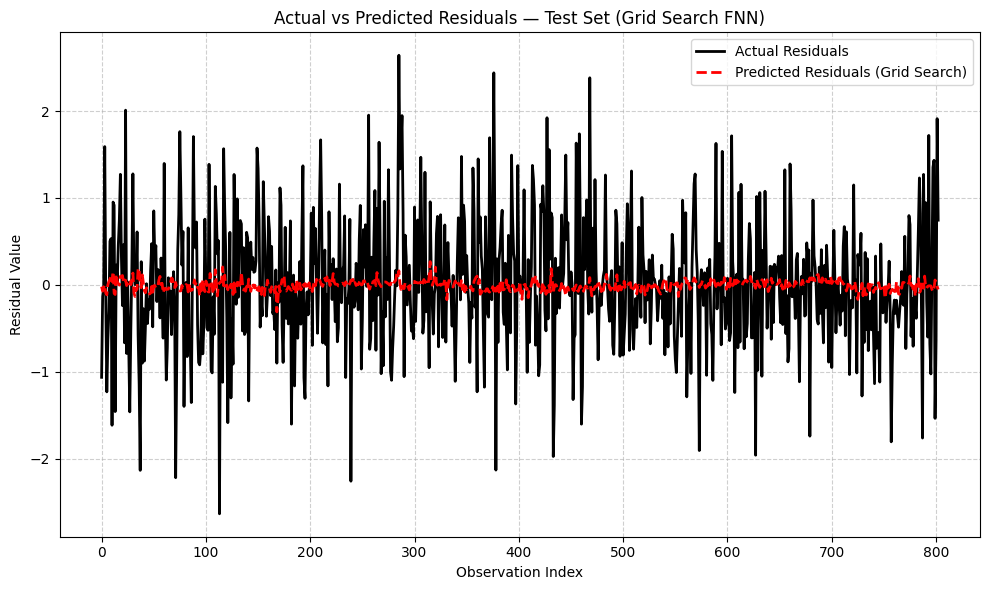


=== Hybrid XGB-FNN (Grid Search) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4579
MSE:  0.2097
MAE:  0.3592
MAPE: 9.8866%
R²:   0.9168

--- Test Metrics ---
RMSE: 0.7253
MSE:  0.5261
MAE:  0.5494
MAPE: 14.7927%
R²:   0.7819


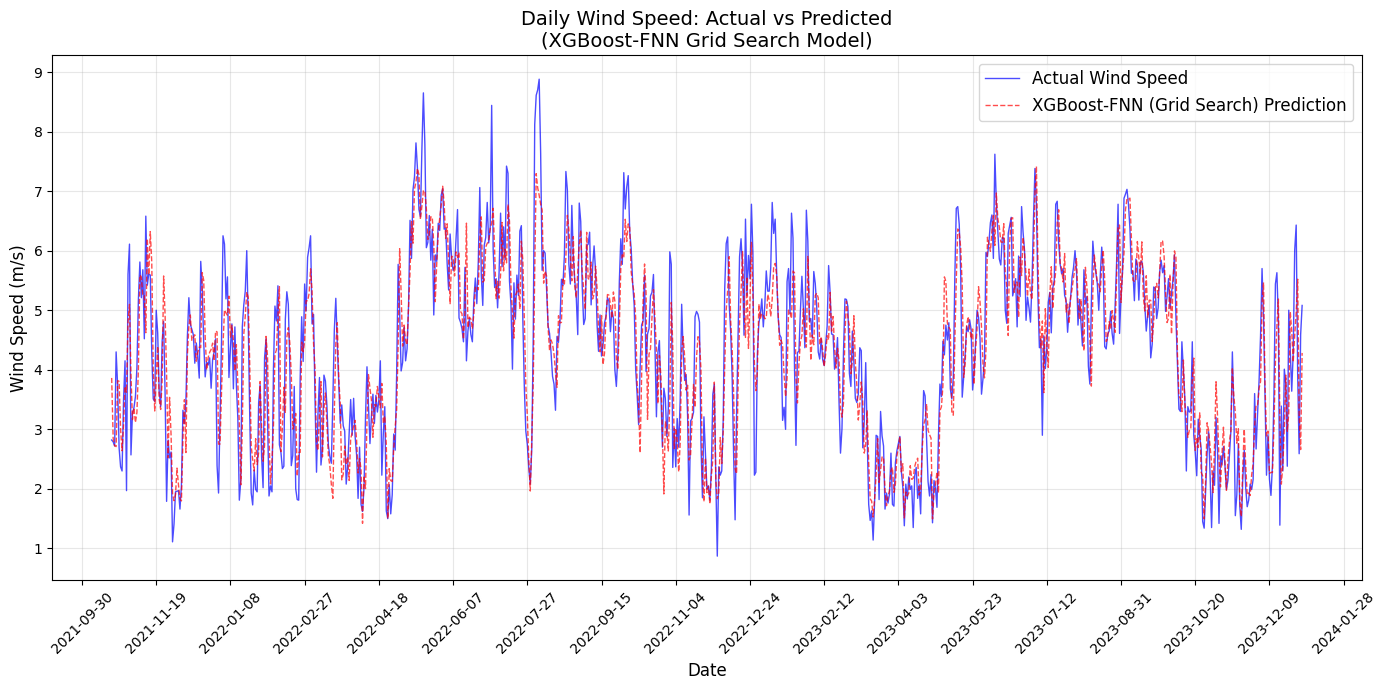

Saved to 'xgb_fnn_df_grid.csv'


In [ ]:
# =============================================================================
# Section 2 — Grid Search FNN
# Exhaustive grid search over the defined parameter grid.
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ────────────────────────
scaler_grid         = StandardScaler()
X_train_scaled_grid = scaler_grid.fit_transform(X_train_res)
X_test_scaled_grid  = scaler_grid.transform(X_test_res)

# ── Parameter grid ───────────────────────────────────────────────────────────
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'activation':         ['relu', 'tanh'],
    'solver':             ['adam'],
    'learning_rate':      ['constant', 'adaptive'],
    'alpha':              [0.0001, 0.001, 0.01],  # L2 regularisation strength
    'max_iter':           [500, 1000]
}

# ── Time series cross-validation (training data only) ───────────────────────
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=MLPRegressor(random_state=RANDOM_SEED),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled_grid, y_train_res)

best_fnn_grid = grid_search.best_estimator_
print("\nBest Parameters (Grid Search):")
print(grid_search.best_params_)

# ── Residual model evaluation ────────────────────────────────────────────────
y_train_pred_grid = best_fnn_grid.predict(X_train_scaled_grid)
y_test_pred_grid  = best_fnn_grid.predict(X_test_scaled_grid)

print("\n--- Grid Search FNN Residual Model Evaluation ---")
evaluate(y_train_res, y_train_pred_grid, label="Train (FNN Grid Search)")
evaluate(y_test_res,  y_test_pred_grid,  label="Test  (FNN Grid Search)")

# Visualise test-set residual predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',
         color='black', linewidth=2)
plt.plot(y_test_pred_grid,  label='Predicted Residuals (Grid Search)',
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Grid Search FNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on full dataset ────────────────────────────────────────
X_full_scaled_grid       = scaler_grid.transform(X_res)
full_pred_residuals_grid  = best_fnn_grid.predict(X_full_scaled_grid).flatten()

df_backup['predicted_residuals_fnn_grid'] = full_pred_residuals_grid

# ── Hybrid prediction: XGB + FNN residual correction ────────────────────────
df_backup['XGB_fnn_grid'] = (df_backup['Pred_XGB_Optuna'] +
                              df_backup['predicted_residuals_fnn_grid'])

# ── Hybrid model performance ─────────────────────────────────────────────────
train_df_grid = df_backup.iloc[:split_index_res].copy()
test_df_grid  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-FNN (Grid Search) Performance on WS10M ===")
train_metrics_grid = evaluate_performance(
    train_df_grid['WS10M'], train_df_grid['XGB_fnn_grid'], set_name="Train")
test_metrics_grid  = evaluate_performance(
    test_df_grid['WS10M'],  test_df_grid['XGB_fnn_grid'],  set_name="Test")

# ── Visualise test-set predictions ──────────────────────────────────────────
test_df_grid.index = pd.to_datetime(test_df_grid.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_grid.index, test_df_grid['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_grid.index, test_df_grid['XGB_fnn_grid'],
         label='XGBoost-FNN (Grid Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-FNN Grid Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_fnn_df_grid = df_backup[fnn_features + ['WS10M', 'XGB_fnn_grid']]
xgb_fnn_df_grid.to_csv('xgb_fnn_df_grid.csv', index=True)
print("Saved to 'xgb_fnn_df_grid.csv'")


## 10. FNN Residual Correction — Randomized Search Hyperparameter Optimisation

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters (Randomized Search):
{'activation': 'tanh', 'alpha': np.float64(0.009522017556848528), 'hidden_layer_sizes': (100,), 'learning_rate': 'adaptive', 'max_iter': 1000, 'solver': 'adam'}

--- Randomized Search FNN Residual Model Evaluation ---
Train (FNN Randomized Search) MSE:  0.2097
Train (FNN Randomized Search) RMSE: 0.4579
Train (FNN Randomized Search) MAE:  0.3592
Train (FNN Randomized Search) MAPE: 1879.84%
Train (FNN Randomized Search) R²:   0.0087
Test  (FNN Randomized Search) MSE:  0.5261
Test  (FNN Randomized Search) RMSE: 0.7253
Test  (FNN Randomized Search) MAE:  0.5494
Test  (FNN Randomized Search) MAPE: 117.57%
Test  (FNN Randomized Search) R²:   0.0022


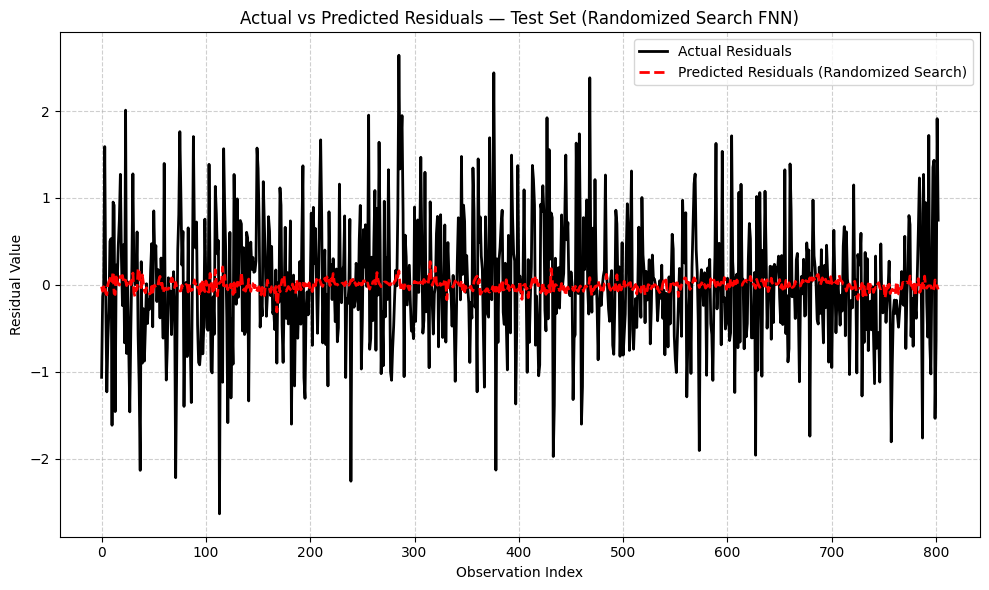

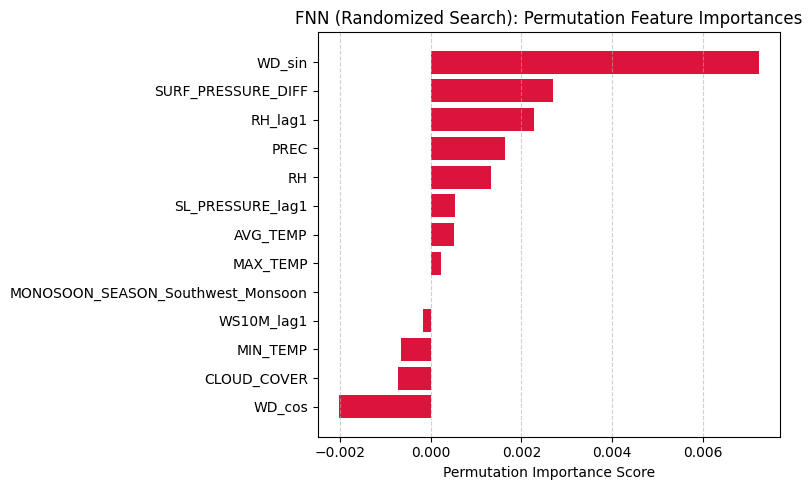


=== Hybrid XGB-FNN (Randomized Search) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4579
MSE:  0.2097
MAE:  0.3592
MAPE: 9.8865%
R²:   0.9168

--- Test Metrics ---
RMSE: 0.7253
MSE:  0.5261
MAE:  0.5494
MAPE: 14.7927%
R²:   0.7819


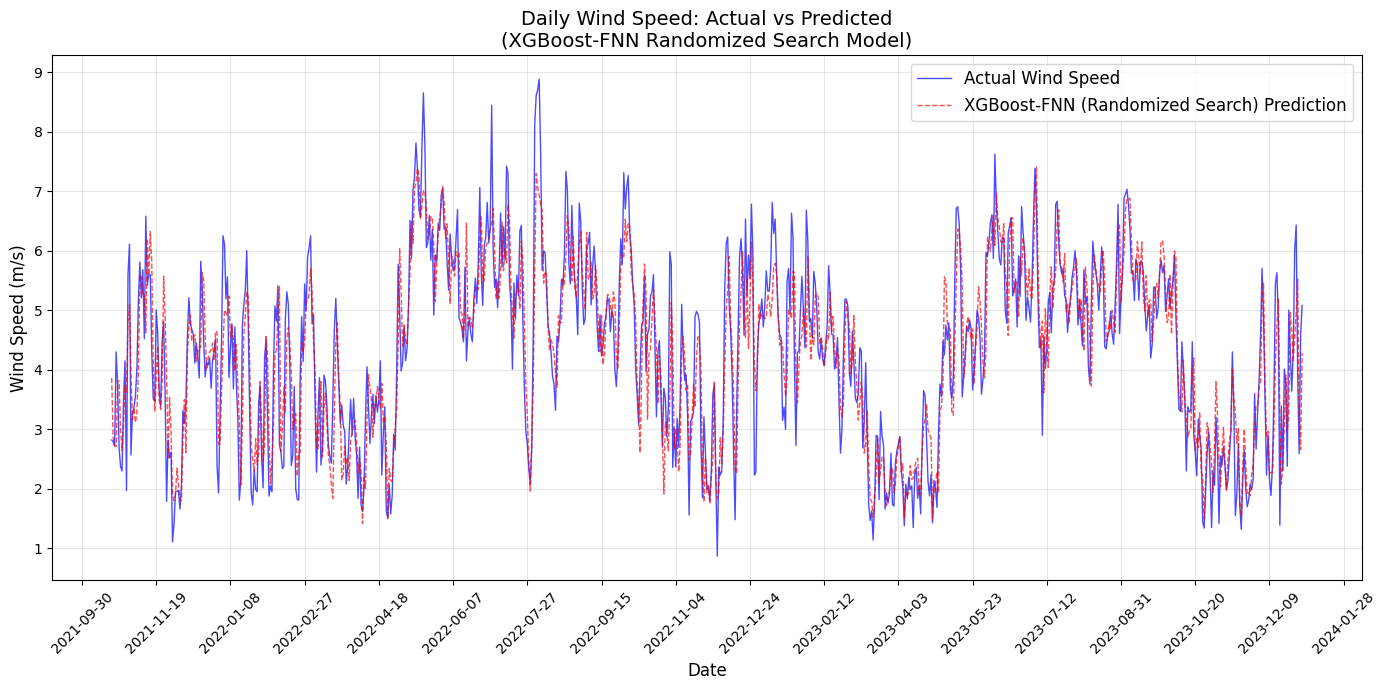

Saved to 'xgb_fnn_df_random.csv'


In [ ]:
# =============================================================================
# Section 3 — Randomized Search FNN
# Random sampling over hyperparameter distributions (30 iterations).
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ────────────────────────
scaler_random        = StandardScaler()
X_train_scaled_rand  = scaler_random.fit_transform(X_train_res)
X_test_scaled_rand   = scaler_random.transform(X_test_res)

# ── Hyperparameter distributions ─────────────────────────────────────────────
param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'activation':         ['relu', 'tanh'],
    'solver':             ['adam'],
    'alpha':              uniform(loc=0.0001, scale=0.01),  # L2 regularisation
    'learning_rate':      ['constant', 'adaptive'],
    'max_iter':           [500, 1000]
}

# ── Time series cross-validation (training data only) ───────────────────────
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=MLPRegressor(random_state=RANDOM_SEED),
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

random_search.fit(X_train_scaled_rand, y_train_res)

best_fnn_random = random_search.best_estimator_
print("\nBest Parameters (Randomized Search):")
print(random_search.best_params_)

# ── Residual model evaluation ────────────────────────────────────────────────
y_train_pred_rand = best_fnn_random.predict(X_train_scaled_rand)
y_test_pred_rand  = best_fnn_random.predict(X_test_scaled_rand)

print("\n--- Randomized Search FNN Residual Model Evaluation ---")
evaluate(y_train_res, y_train_pred_rand, label="Train (FNN Randomized Search)")
evaluate(y_test_res,  y_test_pred_rand,  label="Test  (FNN Randomized Search)")

# Visualise test-set residual predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',
         color='black', linewidth=2)
plt.plot(y_test_pred_rand,  label='Predicted Residuals (Randomized Search)',
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Randomized Search FNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Permutation Feature Importance ──────────────────────────────────────────
perm_result = permutation_importance(
    best_fnn_random, X_test_scaled_rand, y_test_res,
    n_repeats=10, random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)
importance_df = pd.DataFrame({
    'Feature':    X_test_res.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='crimson')
plt.xlabel('Permutation Importance Score')
plt.title('FNN (Randomized Search): Permutation Feature Importances')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on full dataset ────────────────────────────────────────
X_full_scaled_rand        = scaler_random.transform(X_res)
full_pred_residuals_random = best_fnn_random.predict(X_full_scaled_rand).flatten()

df_backup['predicted_residuals_fnn_random'] = full_pred_residuals_random

# ── Hybrid prediction: XGB + FNN residual correction ────────────────────────
df_backup['XGB_fnn_random'] = (df_backup['Pred_XGB_Optuna'] +
                                df_backup['predicted_residuals_fnn_random'])

# ── Hybrid model performance ─────────────────────────────────────────────────
train_df_rand = df_backup.iloc[:split_index_res].copy()
test_df_rand  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-FNN (Randomized Search) Performance on WS10M ===")
train_metrics_rand = evaluate_performance(
    train_df_rand['WS10M'], train_df_rand['XGB_fnn_random'], set_name="Train")
test_metrics_rand  = evaluate_performance(
    test_df_rand['WS10M'],  test_df_rand['XGB_fnn_random'],  set_name="Test")

# ── Visualise test-set predictions ──────────────────────────────────────────
test_df_rand.index = pd.to_datetime(test_df_rand.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_rand.index, test_df_rand['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_rand.index, test_df_rand['XGB_fnn_random'],
         label='XGBoost-FNN (Randomized Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-FNN Randomized Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_fnn_df_random = df_backup[fnn_features + ['WS10M', 'XGB_fnn_random']]
xgb_fnn_df_random.to_csv('xgb_fnn_df_random.csv', index=True)
print("Saved to 'xgb_fnn_df_random.csv'")


## 11. FNN Residual Correction — Optuna Bayesian Optimisation


Best Trial:
FrozenTrial(number=4, state=<TrialState.COMPLETE: 1>, values=[0.2300413536876511], datetime_start=datetime.datetime(2026, 3, 13, 3, 3, 4, 955566), datetime_complete=datetime.datetime(2026, 3, 13, 3, 3, 6, 793962), params={'n_layers': 1, 'n_units_l0': 28, 'activation': 'tanh', 'alpha': 0.002661901888489057, 'learning_rate': 'constant'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_l0': IntDistribution(high=150, log=False, low=20, step=1), 'activation': CategoricalDistribution(choices=('relu', 'tanh')), 'alpha': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'learning_rate': CategoricalDistribution(choices=('constant', 'adaptive'))}, trial_id=4, value=None)

Best Parameters (Optuna):
{'n_layers': 1, 'n_units_l0': 28, 'activation': 'tanh', 'alpha': 0.002661901888489057, 'learning_rate': 'constant'}

--- Optuna FNN Residual Model Evaluation ---
Train (FNN Optuna) MS

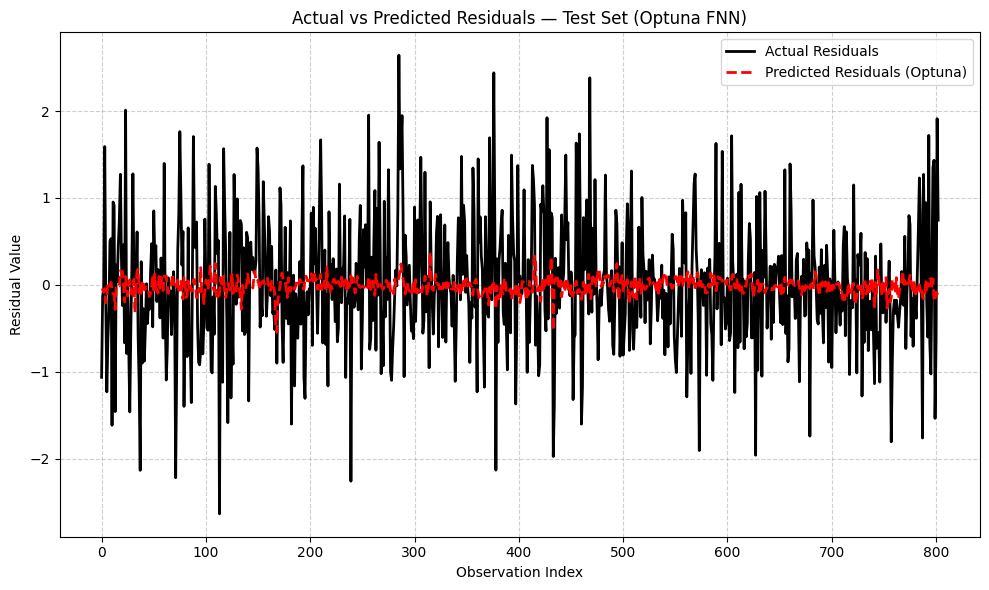

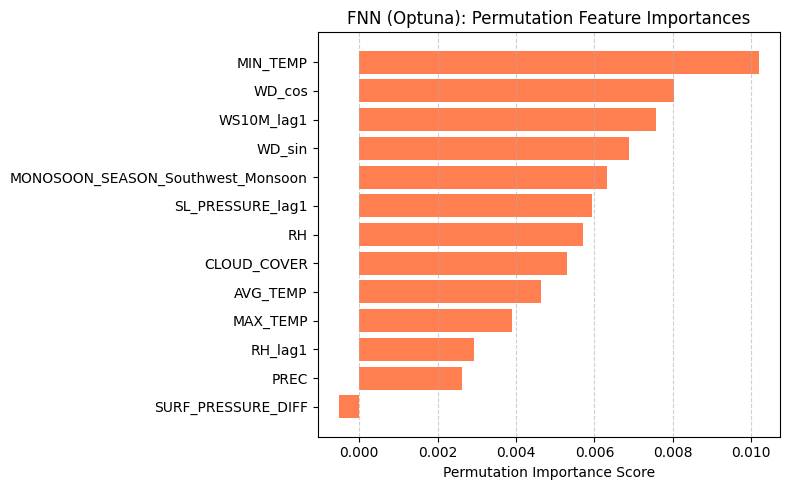


=== Hybrid XGB-FNN (Optuna) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4505
MSE:  0.2029
MAE:  0.3534
MAPE: 9.7200%
R²:   0.9194

--- Test Metrics ---
RMSE: 0.7202
MSE:  0.5187
MAE:  0.5506
MAPE: 14.8151%
R²:   0.7849


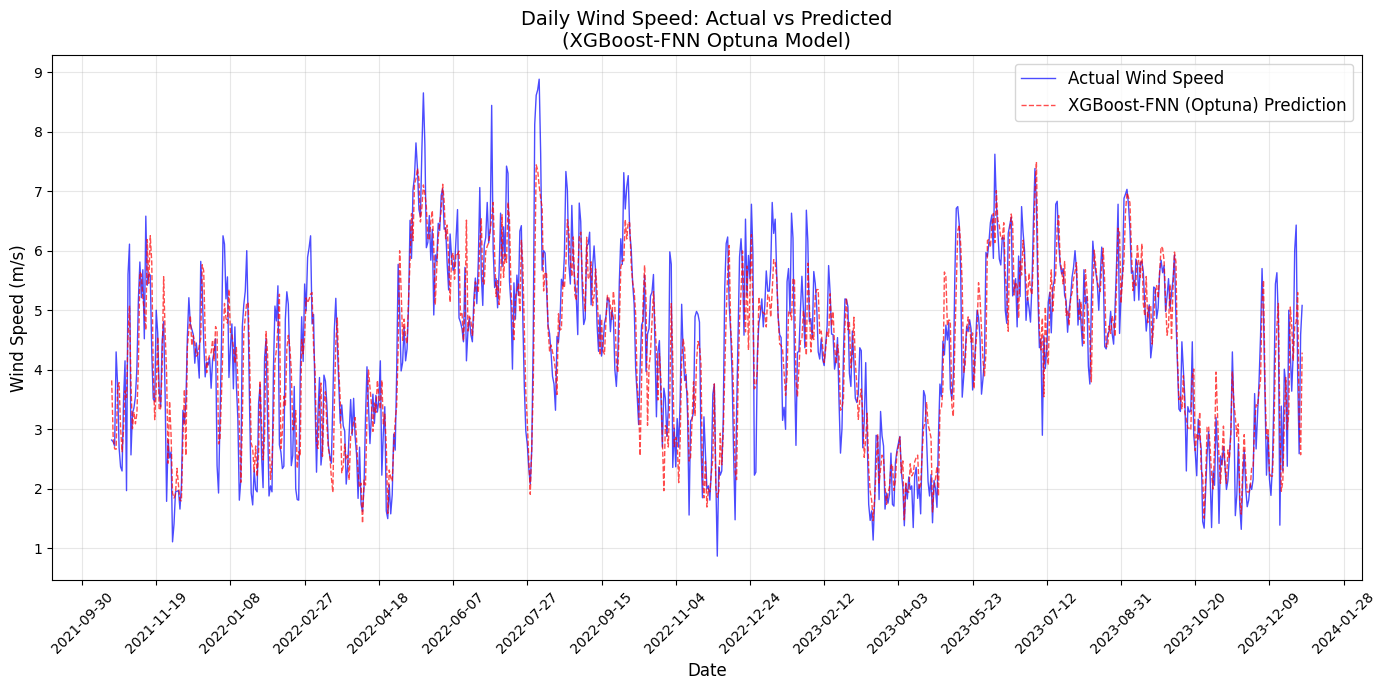

Saved to 'xgb_fnn_df_optuna.csv'


In [8]:
# =============================================================================
# Section 4 — Optuna FNN
# Bayesian (TPE) hyperparameter search over architecture and regularisation.
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# FIX: Optuna objective uses the pre-scaled training array (X_train_scaled_opt)
#      to ensure the FNN sees the same scaled input as the final model.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ────────────────────────
scaler_optuna       = StandardScaler()
X_train_scaled_opt  = scaler_optuna.fit_transform(X_train_res)
X_test_scaled_opt   = scaler_optuna.transform(X_test_res)

# ── Optuna objective function ────────────────────────────────────────────────
def fnn_objective(trial):
    """
    Objective function for Optuna Bayesian optimisation.
    Uses pre-scaled training data and TimeSeriesSplit for cross-validation.
    """
    # Suggest architecture: number of layers and units per layer
    n_layers           = trial.suggest_int('n_layers', 1, 3)
    hidden_layer_sizes = tuple(
        trial.suggest_int(f'n_units_l{i}', 20, 150)
        for i in range(n_layers)
    )

    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation':    trial.suggest_categorical('activation',
                                                   ['relu', 'tanh']),
        'solver':        'adam',  # fixed
        'alpha':         trial.suggest_float('alpha', 1e-5, 1e-2, log=True),  # L2 regularisation
        'learning_rate': trial.suggest_categorical('learning_rate',
                                                   ['constant', 'adaptive']),
        'max_iter':      1000,
        'random_state':  RANDOM_SEED
    }

    # Time series cross-validation on scaled training data only
    tscv       = TimeSeriesSplit(n_splits=5)
    mse_scores = []

    for train_idx, val_idx in tscv.split(X_train_scaled_opt):
        # Use pre-scaled numpy arrays (avoids double-scaling / data leakage)
        X_t = X_train_scaled_opt[train_idx]
        X_v = X_train_scaled_opt[val_idx]
        y_t = y_train_res.iloc[train_idx]
        y_v = y_train_res.iloc[val_idx]

        model = MLPRegressor(**params)
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        mse_scores.append(mean_squared_error(y_v, preds))

    return np.mean(mse_scores)

# ── Create and run Optuna study ──────────────────────────────────────────────
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
# max 30 trials or 10 minutes, whichever comes first
study.optimize(fnn_objective, n_trials=30, timeout=600)

print("\nBest Trial:")
print(study.best_trial)
print("\nBest Parameters (Optuna):")
print(study.best_params)

# ── Reconstruct architecture from best Optuna parameters ────────────────────
best_params_opt        = study.best_params
hidden_layer_sizes_opt = tuple(
    best_params_opt[f'n_units_l{i}']
    for i in range(best_params_opt['n_layers'])
)

# ── Refit final model on full training data ──────────────────────────────────
final_fnn_optuna = MLPRegressor(
    hidden_layer_sizes=hidden_layer_sizes_opt,
    activation=best_params_opt['activation'],
    solver='adam',
    alpha=best_params_opt['alpha'],
    learning_rate=best_params_opt['learning_rate'],
    max_iter=1000,
    random_state=RANDOM_SEED
)
final_fnn_optuna.fit(X_train_scaled_opt, y_train_res)

# ── Residual model evaluation ────────────────────────────────────────────────
y_train_pred_opt = final_fnn_optuna.predict(X_train_scaled_opt)
y_test_pred_opt  = final_fnn_optuna.predict(X_test_scaled_opt)

print("\n--- Optuna FNN Residual Model Evaluation ---")
evaluate(y_train_res, y_train_pred_opt, label="Train (FNN Optuna)")
evaluate(y_test_res,  y_test_pred_opt,  label="Test  (FNN Optuna)")

# Visualise test-set residual predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',
         color='black', linewidth=2)
plt.plot(y_test_pred_opt,   label='Predicted Residuals (Optuna)',
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Optuna FNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Permutation Feature Importance ──────────────────────────────────────────
perm_result_opt = permutation_importance(
    final_fnn_optuna, X_test_scaled_opt, y_test_res,
    n_repeats=10, random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)
importance_df_opt = pd.DataFrame({
    'Feature':    X_test_res.columns,
    'Importance': perm_result_opt.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df_opt['Feature'], importance_df_opt['Importance'],
         color='coral')
plt.xlabel('Permutation Importance Score')
plt.title('FNN (Optuna): Permutation Feature Importances')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on full dataset ────────────────────────────────────────
X_full_scaled_opt         = scaler_optuna.transform(X_res)
full_pred_residuals_optuna = final_fnn_optuna.predict(X_full_scaled_opt).flatten()

df_backup['predicted_residuals_fnn_optuna'] = full_pred_residuals_optuna

# ── Hybrid prediction: XGB + FNN residual correction ────────────────────────
df_backup['XGB_fnn_optuna'] = (df_backup['Pred_XGB_Optuna'] +
                                df_backup['predicted_residuals_fnn_optuna'])

# ── Hybrid model performance ─────────────────────────────────────────────────
train_df_opt = df_backup.iloc[:split_index_res].copy()
test_df_opt  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-FNN (Optuna) Performance on WS10M ===")
train_metrics_opt = evaluate_performance(
    train_df_opt['WS10M'], train_df_opt['XGB_fnn_optuna'], set_name="Train")
test_metrics_opt  = evaluate_performance(
    test_df_opt['WS10M'],  test_df_opt['XGB_fnn_optuna'],  set_name="Test")

# ── Visualise test-set predictions ──────────────────────────────────────────
test_df_opt.index = pd.to_datetime(test_df_opt.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_opt.index, test_df_opt['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_opt.index, test_df_opt['XGB_fnn_optuna'],
         label='XGBoost-FNN (Optuna) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-FNN Optuna Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_fnn_df_optuna = df_backup[fnn_features + ['WS10M', 'XGB_fnn_optuna']]
xgb_fnn_df_optuna.to_csv('xgb_fnn_df_optuna.csv', index=True)
print("Saved to 'xgb_fnn_df_optuna.csv'")


In [9]:
# ── Export test-set actuals and predictions for Diebold-Mariano test ─────────
dm_test_df = test_df_opt[['WS10M', 'XGB_fnn_optuna']].copy()
dm_test_df['residuals_XGB_FNN_Optuna'] = dm_test_df['WS10M'] - dm_test_df['XGB_fnn_optuna']
dm_test_df.to_csv('dm_test_xgb_fnn_optuna.csv', index=True)
print("Saved to 'dm_test_xgb_fnn_optuna.csv'")

Saved to 'dm_test_xgb_fnn_optuna.csv'


## 12. Comprehensive Performance Comparison Across All Methods

In [ ]:
# =============================================================================
# Summary comparison of all four XGBoost-FNN hybrid model variants.
# Method labels: "Original Model", "Grid Search", "Randomized Search", "Optuna"
# =============================================================================

actual = df_backup['WS10M']

# Map human-readable method names to dataframe column names
methods_map = {
    'Original Model':    'XGB_fnn_original',
    'Grid Search':       'XGB_fnn_grid',
    'Randomized Search': 'XGB_fnn_random',
    'Optuna':            'XGB_fnn_optuna'
}

split_idx    = int(0.8 * len(df_backup))
train_actual = actual.iloc[:split_idx]
test_actual  = actual.iloc[split_idx:]

results = []
for method_name, col_name in methods_map.items():
    pred       = df_backup[col_name]
    train_pred = pred.iloc[:split_idx]
    test_pred  = pred.iloc[split_idx:]

    results.append({
        'Method':         method_name,
        'Train MSE':      mean_squared_error(train_actual, train_pred),
        'Test MSE':       mean_squared_error(test_actual,  test_pred),
        'Train MAE':      mean_absolute_error(train_actual, train_pred),
        'Test MAE':       mean_absolute_error(test_actual,  test_pred),
        'Train RMSE':     np.sqrt(mean_squared_error(train_actual, train_pred)),
        'Test RMSE':      np.sqrt(mean_squared_error(test_actual,  test_pred)),
        'Train MAPE (%)': np.mean(np.abs((train_actual - train_pred) / train_actual)) * 100,
        'Test MAPE (%)':  np.mean(np.abs((test_actual  - test_pred)  / test_actual))  * 100,
        'Train R²':       r2_score(train_actual, train_pred),
        'Test R²':        r2_score(test_actual,  test_pred)
    })

results_df = pd.DataFrame(results)
print("\n=== XGBoost-FNN Hybrid Model Performance Comparison ===")
print(results_df.to_string(index=False))

# Save the full comparison to CSV
results_df.to_csv('xgb_fnn_all_models_performance.csv', index=False)
print("\nSaved to 'xgb_fnn_all_models_performance.csv'")

# ── Plotly summary table ─────────────────────────────────────────────────────
numeric_cols = [c for c in results_df.columns if c != 'Method']
display_df   = results_df.copy()
for col in numeric_cols:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.6f}")

fig_summary = go.Figure(go.Table(
    header=dict(
        values=[f'<b>{c}</b>' for c in results_df.columns],
        fill_color='steelblue',
        font=dict(color='white', size=11),
        align='center'
    ),
    cells=dict(
        values=[display_df[c] for c in display_df.columns],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(display_df))]],
        align='center'
    )
))
fig_summary.update_layout(
    title="XGBoost-FNN Hybrid Models — Full Performance Comparison",
    template="plotly_white",
    height=300
)
fig_summary.show()



=== XGBoost-FNN Hybrid Model Performance Comparison ===
           Method  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model   0.073929  0.612448   0.210034  0.608728    0.271899   0.782591        5.724486      16.726814  0.970655 0.746024
      Grid Search   0.209692  0.526056   0.359238  0.549438    0.457922   0.725297        9.886551      14.792727  0.916766 0.781850
Randomized Search   0.209690  0.526054   0.359236  0.549436    0.457920   0.725296        9.886484      14.792654  0.916766 0.781851
           Optuna   0.202948  0.518732   0.353429  0.550571    0.450498   0.720230        9.720013      14.815089  0.919443 0.784887

Saved to 'xgb_fnn_all_models_performance.csv'
